In [8]:
import os.path, time
import onnxruntime as ort
import pandas as pd
import numpy as np

from utils.dataset import load_dataset_v2, create_lstm_dataset
from tqdm.notebook import tqdm

In [9]:
model = ort.InferenceSession('lstm_model.onnx')

In [10]:
file_name_list = os.listdir(os.path.join('data', 'ver_2'))
file_path_list = []

for file_name in file_name_list:
    file_path_list.append(os.path.join('data', 'ver_2', file_name))

start_time = time.strftime('%Y%m%d-%H%M%S', time.localtime(time.time()))

dataset = load_dataset_v2(file_path_list)
time_dt_arr = np.concatenate([np.array([0]), np.diff(dataset['time(s)'].to_numpy())])
dataset = pd.concat([pd.DataFrame(time_dt_arr, columns=['time_diff(s)']), dataset], axis=1)

loading dataset...:   0%|          | 0/84 [00:00<?, ?it/s]

In [11]:
dataset = dataset[dataset['outlet_flowrate(lpm)'] > 1]
dataset = dataset[::10]
dataset.reset_index(drop=True, inplace=True)
dataset.shape

(196560, 19)

In [12]:
feature_col_name_list = ['pressure_1(bar)', 'main_pressure(bar)']
target_col_name = 'outlet_flowrate(lpm)'

train_data = dataset[dataset['test_case_iter']!=3]
train_data.reset_index(drop=True, inplace=True)

val_data = dataset[dataset['test_case_iter']==3]
val_data.reset_index(drop=True, inplace=True)

train_feature = train_data[feature_col_name_list]
train_target = pd.DataFrame(train_data[target_col_name])

val_feature = val_data[feature_col_name_list]
val_target = pd.DataFrame(val_data[target_col_name])

In [13]:
seq_len = 30
pred_distance = 0

train_feature, train_target = create_lstm_dataset(train_data[feature_col_name_list+[target_col_name]].to_numpy(), seq_len=seq_len,
                                                  pred_distance=pred_distance, target_idx_pos=2)
val_feature, val_target = create_lstm_dataset(val_data[feature_col_name_list+[target_col_name]].to_numpy(), seq_len=seq_len,
                                              pred_distance=pred_distance, target_idx_pos=2)

  0%|          | 0/132560 [00:00<?, ?it/s]

  0%|          | 0/64000 [00:00<?, ?it/s]

In [14]:
train_feature = train_feature.astype(np.float32)
train_target = train_target.astype(np.float32)

time_list = []
train_pred = []

for input_data in tqdm(train_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    train_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/132531 [00:00<?, ?it/s]

Average inference time per data sequence: 0.485 mile seconds


In [15]:
val_feature = val_feature.astype(np.float32)
val_target = val_target.astype(np.float32)

time_list = []
val_pred = []

for input_data in tqdm(val_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    val_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/63971 [00:00<?, ?it/s]

Average inference time per data sequence: 0.486 mile seconds


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

In [17]:
print(r2_score(train_target, train_pred), r2_score(val_target, val_pred))
print(mean_absolute_error(train_target, train_pred), mean_absolute_error(val_target, val_pred))
print(mean_absolute_percentage_error(train_target, train_pred), mean_absolute_percentage_error(val_target, val_pred))

0.9702420234680176 0.945232629776001
55.17516326904297 76.18841552734375
0.1313788890838623 0.2338048368692398


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
data = val_data.iloc[seq_len-1:]
data.reset_index(drop=True, inplace=True)
data = pd.concat([data, pd.DataFrame({'pred_outlet_flowrate(lpm)': val_pred})], axis=1)

abs_error = np.abs(data['outlet_flowrate(lpm)'].to_numpy()-data['pred_outlet_flowrate(lpm)'].to_numpy())
rela_error = (abs_error / data['outlet_flowrate(lpm)'].to_numpy())*100

val_data_slice =  pd.concat([data, pd.DataFrame({'abs_error': abs_error,'relative_error': rela_error})], axis=1)

In [20]:
val_data_slice.head()

,time_diff(s),time(s),pressure_1(bar),main_pressure(bar),venturi_pressure_1(bar),venturi_pressure_2(bar),venturi_pressure_3(bar),venturi_pressure_4(bar),venturi_pressure_5(bar),pump_speed(rpm),...,outlet_flowrate(lpm),inlet_flowrate(lpm),test_case,test_case_iter,nozzle_len(mm),nozzle_dia(mm),venturi_dist(mm),pred_outlet_flowrate(lpm),abs_error,relative_error
0,0.01,47.07,-0.20,7.38,7.40,0.00,0.04,-0.02,0.09,904.36,...,636.34,-3.04,1.0,3.0,12.0,12.0,0.0,974.227722,337.887722,53.098614
1,0.01,47.17,-0.14,7.22,7.53,0.08,0.08,0.01,0.02,887.81,...,642.77,-2.63,1.0,3.0,12.0,12.0,0.0,1129.649170,486.879170,75.747028
2,0.01,47.27,-0.07,7.58,7.53,0.02,-0.01,-0.06,-0.00,882.19,...,655.31,-2.32,1.0,3.0,12.0,12.0,0.0,1121.360718,466.050718,71.119122
3,0.01,47.37,-0.18,7.19,7.42,-0.00,0.03,0.12,0.23,900.27,...,664.01,-2.36,1.0,3.0,12.0,12.0,0.0,1121.515015,457.505015,68.900320
4,0.01,47.47,-0.15,7.32,7.46,0.09,0.07,0.01,-0.00,891.20,...,682.30,-2.94,1.0,3.0,12.0,12.0,0.0,1121.223511,438.923511,64.329988


Text(0, 0.5, 'Relative error (%)')

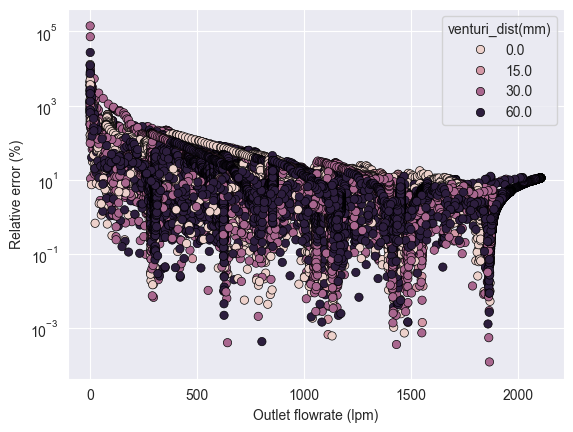

In [21]:
sns.scatterplot(data=val_data_slice, x='outlet_flowrate(lpm)', y='relative_error', hue='venturi_dist(mm)', edgecolor='black')

plt.xlabel('Outlet flowrate (lpm)')

plt.yscale('log')
plt.ylabel('Relative error (%)')

In [22]:
pump_speed_1_df = val_data_slice[(val_data_slice['pump_speed(rpm)'] > 850) & (val_data_slice['pump_speed(rpm)'] < 950)]
pump_speed_1_df.reset_index(drop=True, inplace=True)
pump_speed_1_df_fix = pump_speed_1_df.copy()
pump_speed_1_df_fix['pump_speed(rpm)'] = 900

pump_speed_2_df = val_data_slice[(val_data_slice['pump_speed(rpm)'] > 1150) & (val_data_slice['pump_speed(rpm)'] < 1250)]
pump_speed_2_df.reset_index(drop=True, inplace=True)
pump_speed_2_df_fix = pump_speed_2_df.copy()
pump_speed_2_df_fix['pump_speed(rpm)'] = 1200

pump_speed_3_df = val_data_slice[(val_data_slice['pump_speed(rpm)'] > 1450) & (val_data_slice['pump_speed(rpm)'] < 1550)]
pump_speed_3_df.reset_index(drop=True, inplace=True)
pump_speed_3_df_fix = pump_speed_3_df.copy()
pump_speed_3_df_fix['pump_speed(rpm)'] = 1500

pump_speed_df = pd.concat([pump_speed_1_df_fix, pump_speed_2_df_fix, pump_speed_3_df_fix])

In [23]:
stats = pump_speed_1_df_fix[['relative_error', 'abs_error']].describe()
stats

,relative_error,abs_error
count,23881.000000,23881.000000
mean,39.529022,110.274334
std,1031.657418,107.671620
min,0.000410,0.002634
25%,4.824829,26.883158
50%,12.294423,76.149526
75%,33.154779,161.831096
max,140853.538347,1422.620737


Text(0, 0.5, 'Relative Error(%)')

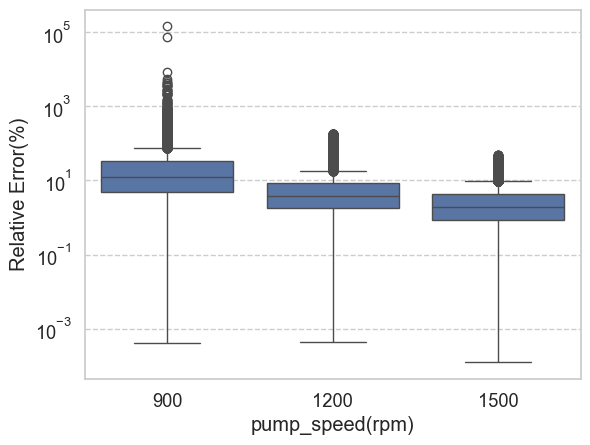

In [24]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='pump_speed(rpm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

Text(0, 0.5, 'Relative Error(%)')

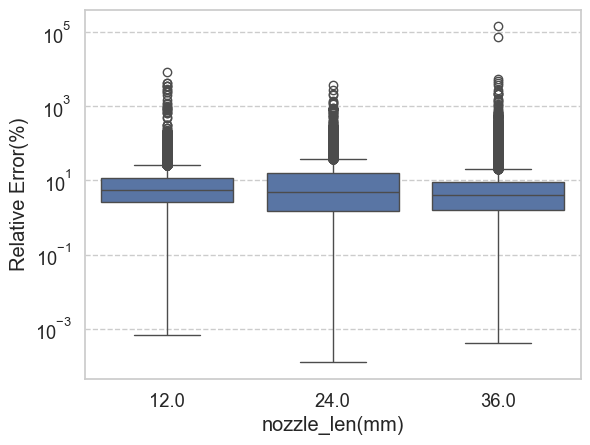

In [25]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='nozzle_len(mm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

Text(0, 0.5, 'Relative Error(%)')

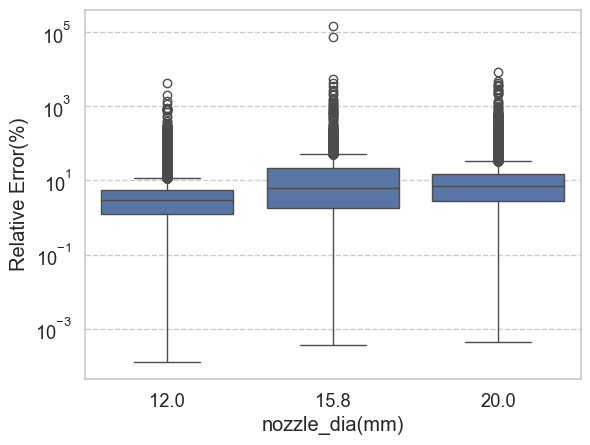

In [26]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='nozzle_dia(mm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

Text(0, 0.5, 'Relative Error(%)')

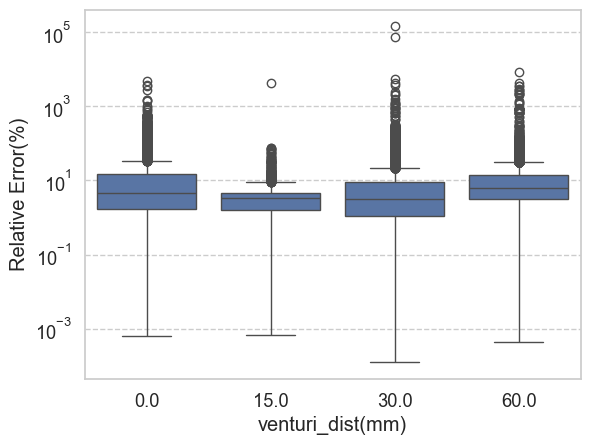

In [27]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='venturi_dist(mm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

<Axes: >

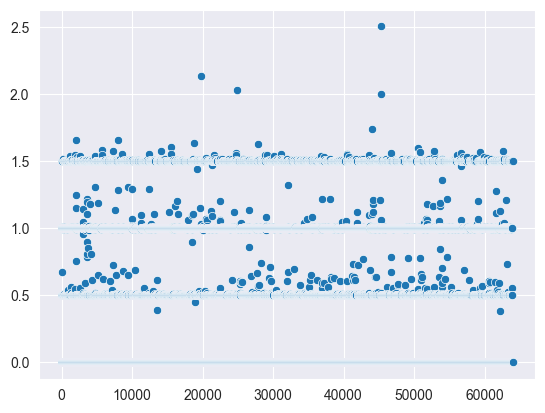

In [21]:
sns.scatterplot(np.array(time_list)*1000)

#plt.ylim(0, 5)